# Practicing Word2Vec

In [1]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("paths.csv")
df.head(10)

,id,text,v_path,label
0,1,i didn't even want to go in there everyhere i ...,/kaggle/input/voice-dataset/1-W-ang.wav,ang
1,2,how can you speak so passionately about someth...,/kaggle/input/voice-dataset/2-W-ang.wav,ang
2,3,everything i have ever cared about is gone,/kaggle/input/voice-dataset/3-W-sad.wav,sad
3,4,i just want be a doctor or anything to help my...,/kaggle/input/voice-dataset/4-W-sad.wav,sad
4,5,i was pushing towards success and my mentor GP...,/kaggle/input/voice-dataset/5-W-happy.wav,hap
5,6,"dont judge me. i like rainbow, sparkles and un...",/kaggle/input/voice-dataset/6-W-happy.wav,hap
6,7,but i say you are executing his soul!,/kaggle/input/voice-dataset/7-W-ang.wav,ang
7,8,for all of gaza becouse they've been attacked ...,/kaggle/input/voice-dataset/8-W-sad.wav,sad
8,9,he broke up with me he dumped me for good,/kaggle/input/voice-dataset/9-W-sad.wav,sad
9,10,"Yeah, you want to see my supervisor? Huh? Yeah...",/kaggle/input/voice-dataset/10-W-ang.wav,ang


In [3]:
df.shape

(60, 4)

In [4]:
df = df.drop(columns=['v_path'])
df.head()

,id,text,label
0,1,i didn't even want to go in there everyhere i ...,ang
1,2,how can you speak so passionately about someth...,ang
2,3,everything i have ever cared about is gone,sad
3,4,i just want be a doctor or anything to help my...,sad
4,5,i was pushing towards success and my mentor GP...,hap


In [5]:
df['label'].unique()

array(['ang', 'sad', 'hap', 'neu'], dtype=object)

In [6]:
# changing the words inside a column

word_replace = {
    'ang':'angry',
    'hap':'happy',
    'neu':'neutral'
}


df['label'] = df['label'].replace(word_replace, regex=True)

df.head()

,id,text,label
0,1,i didn't even want to go in there everyhere i ...,angry
1,2,how can you speak so passionately about someth...,angry
2,3,everything i have ever cared about is gone,sad
3,4,i just want be a doctor or anything to help my...,sad
4,5,i was pushing towards success and my mentor GP...,happy


In [7]:
# using LabelEncoder on label
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [8]:
df['label'] = le.fit_transform(df['label'])
df.head()

,id,text,label
0,1,i didn't even want to go in there everyhere i ...,0
1,2,how can you speak so passionately about someth...,0
2,3,everything i have ever cared about is gone,3
3,4,i just want be a doctor or anything to help my...,3
4,5,i was pushing towards success and my mentor GP...,1


In [9]:
# checking what word got changed into what label
for num, word in enumerate(le.classes_):
  print(f"{word:<20} : {num}")


angry                : 0
happy                : 1
neutral              : 2
sad                  : 3


In [10]:
df['text'].head()

,text
0,i didn't even want to go in there everyhere i ...
1,how can you speak so passionately about someth...
2,everything i have ever cared about is gone
3,i just want be a doctor or anything to help my...
4,i was pushing towards success and my mentor GP...


In [11]:
# copying df into 'data' for EDA
data = df.copy()
data.head()

,id,text,label
0,1,i didn't even want to go in there everyhere i ...,0
1,2,how can you speak so passionately about someth...,0
2,3,everything i have ever cared about is gone,3
3,4,i just want be a doctor or anything to help my...,3
4,5,i was pushing towards success and my mentor GP...,1


In [12]:
!pip install cleantext

In [13]:
import nltk

from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
# Download the stop words list
nltk.download('stopwords')
stop_words = stopwords.words('english')

from nltk.stem import WordNetLemmatizer
# Download the WordNet dictionary (for the lemmatizer)
nltk.download('wordnet')
lmt = WordNetLemmatizer()

from cleantext import clean
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [15]:
# making a function
  # lowercase
  # word tokenizer
  # stopwords
  # lemmatization

def transform(txt):
  txt = clean(
      txt,
      lowercase=True,
      punct=True
  )

  txt = word_tokenize(txt)

  temp = []

  for words in txt:
    if words not in stop_words:
      words = lmt.lemmatize(words, pos='v')
      temp.append(words)

  return " ".join(temp)




In [16]:
transform('Hello i am always addcted to playing games !!!')

'hello always addcted play game'

In [17]:
data['text'] = data['text'].apply(transform)
data.head()

,id,text,label
0,1,didnt even want go everyhere go people look li...,0
1,2,speak passionately something wasnt witness,0
2,3,everything ever care go,3
3,4,want doctor anything help people cant im kid,3
4,5,push towards success mentor gps announce youve...,1


In [18]:
data_math = tfidf.fit_transform(data['text'])
print(len(data_math.toarray()))
print()
print(f"Length of the unique words : {len(tfidf.get_feature_names_out())}")
print()
print(tfidf.get_feature_names_out())

60

Length of the unique words : 277

['advice' 'affairs' 'ambulances' 'american' 'amm' 'announce' 'another'
 'anything' 'around' 'arrest' 'arrive' 'assign' 'assume' 'attack'
 'attorney' 'aunt' 'back' 'bad' 'barrack' 'bay' 'becouse' 'belly' 'break'
 'caffe' 'call' 'cant' 'care' 'century' 'ceo' 'charge' 'claim' 'closest'
 'code' 'colonel' 'come' 'complicate' 'contact' 'corporal' 'corporals'
 'could' 'counsel' 'counterpart' 'criminal' 'cross' 'cuba' 'cuban' 'cute'
 'damn' 'daniel' 'danny' 'daughter' 'dawson' 'dawsons' 'day' 'defend'
 'degenerate' 'destroy' 'didnt' 'discuss' 'division' 'doctor' 'dont'
 'downey' 'downeys' 'dump' 'either' 'entitle' 'equilibrium' 'even' 'ever'
 'every' 'everyhere' 'everything' 'exchange' 'execute' 'face' 'family'
 'fanatical' 'father' 'fault' 'fence' 'finally' 'fine' 'finish' 'fire'
 'flame' 'flight' 'follow' 'food' 'form' 'friend' 'galactically' 'gaza'
 'get' 'girl' 'give' 'go' 'gon' 'good' 'government' 'gps' 'guantanamo'
 'guess' 'gun' 'guy' 'hadnt' 'hand'

In [19]:
# converting data_math into a data frame

features = tfidf.get_feature_names_out()

data_math = pd.DataFrame(data_math.toarray(), columns=features)

In [20]:
print(data_math.shape)
data_math.head()

(60, 277)


,advice,affairs,ambulances,american,amm,announce,another,anything,around,arrest,...,worst,would,wouldnt,write,wrong,yeah,year,yes,youre,youve
0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.363389,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.32146,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.291956


### EDA

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
data_math['label'] = data['label'].copy()

In [23]:
# replacing the labels into words again for better EDA
word_replace = {
    0:'angry',
    1:'happy',
    2:'neutral',
    3:'sad'
}

data_math['label'] = data_math['label'].replace(word_replace, regex=True)
data_math['label'].head()

,label
0,angry
1,angry
2,sad
3,sad
4,happy


In [24]:
grouped_data = data_math.groupby('label').mean(numeric_only=True)
# here mean is being used to find which word is being used most and least of the time
grouped_data

,advice,affairs,ambulances,american,amm,announce,another,anything,around,arrest,...,worst,would,wouldnt,write,wrong,yeah,year,yes,youre,youve
label,,,,,,,,,,,,,,,,,,,,,
angry,0.02381,0.0166,0.000000,0.000000,0.000000,0.000000,0.0000,0.028284,0.000000,0.017352,...,0.013919,0.027355,0.033,0.000000,0.020957,0.023174,0.000000,0.015627,0.000000,0.000000
happy,0.00000,0.0000,0.000000,0.000000,0.000000,0.035718,0.0000,0.000000,0.033660,0.000000,...,0.000000,0.024400,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032440
neutral,0.00000,0.0000,0.000000,0.016693,0.027623,0.000000,0.0221,0.000000,0.019597,0.000000,...,0.000000,0.019491,0.000,0.018402,0.000000,0.000000,0.028101,0.000000,0.023676,0.019802
sad,0.00000,0.0000,0.025519,0.000000,0.000000,0.000000,0.0000,0.024226,0.000000,0.000000,...,0.000000,0.023263,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076047,0.000000


In [25]:
# making four different objects for four different labels

# by doing ascending=False it will put words with higher numbers in a descending order
angry = grouped_data.iloc[0].sort_values(ascending=False).head(20)
happy = grouped_data.iloc[1].sort_values(ascending=False).head(20)
neutral = grouped_data.iloc[2].sort_values(ascending=False).head(20)
sad = grouped_data.iloc[3].sort_values(ascending=False).head(20)

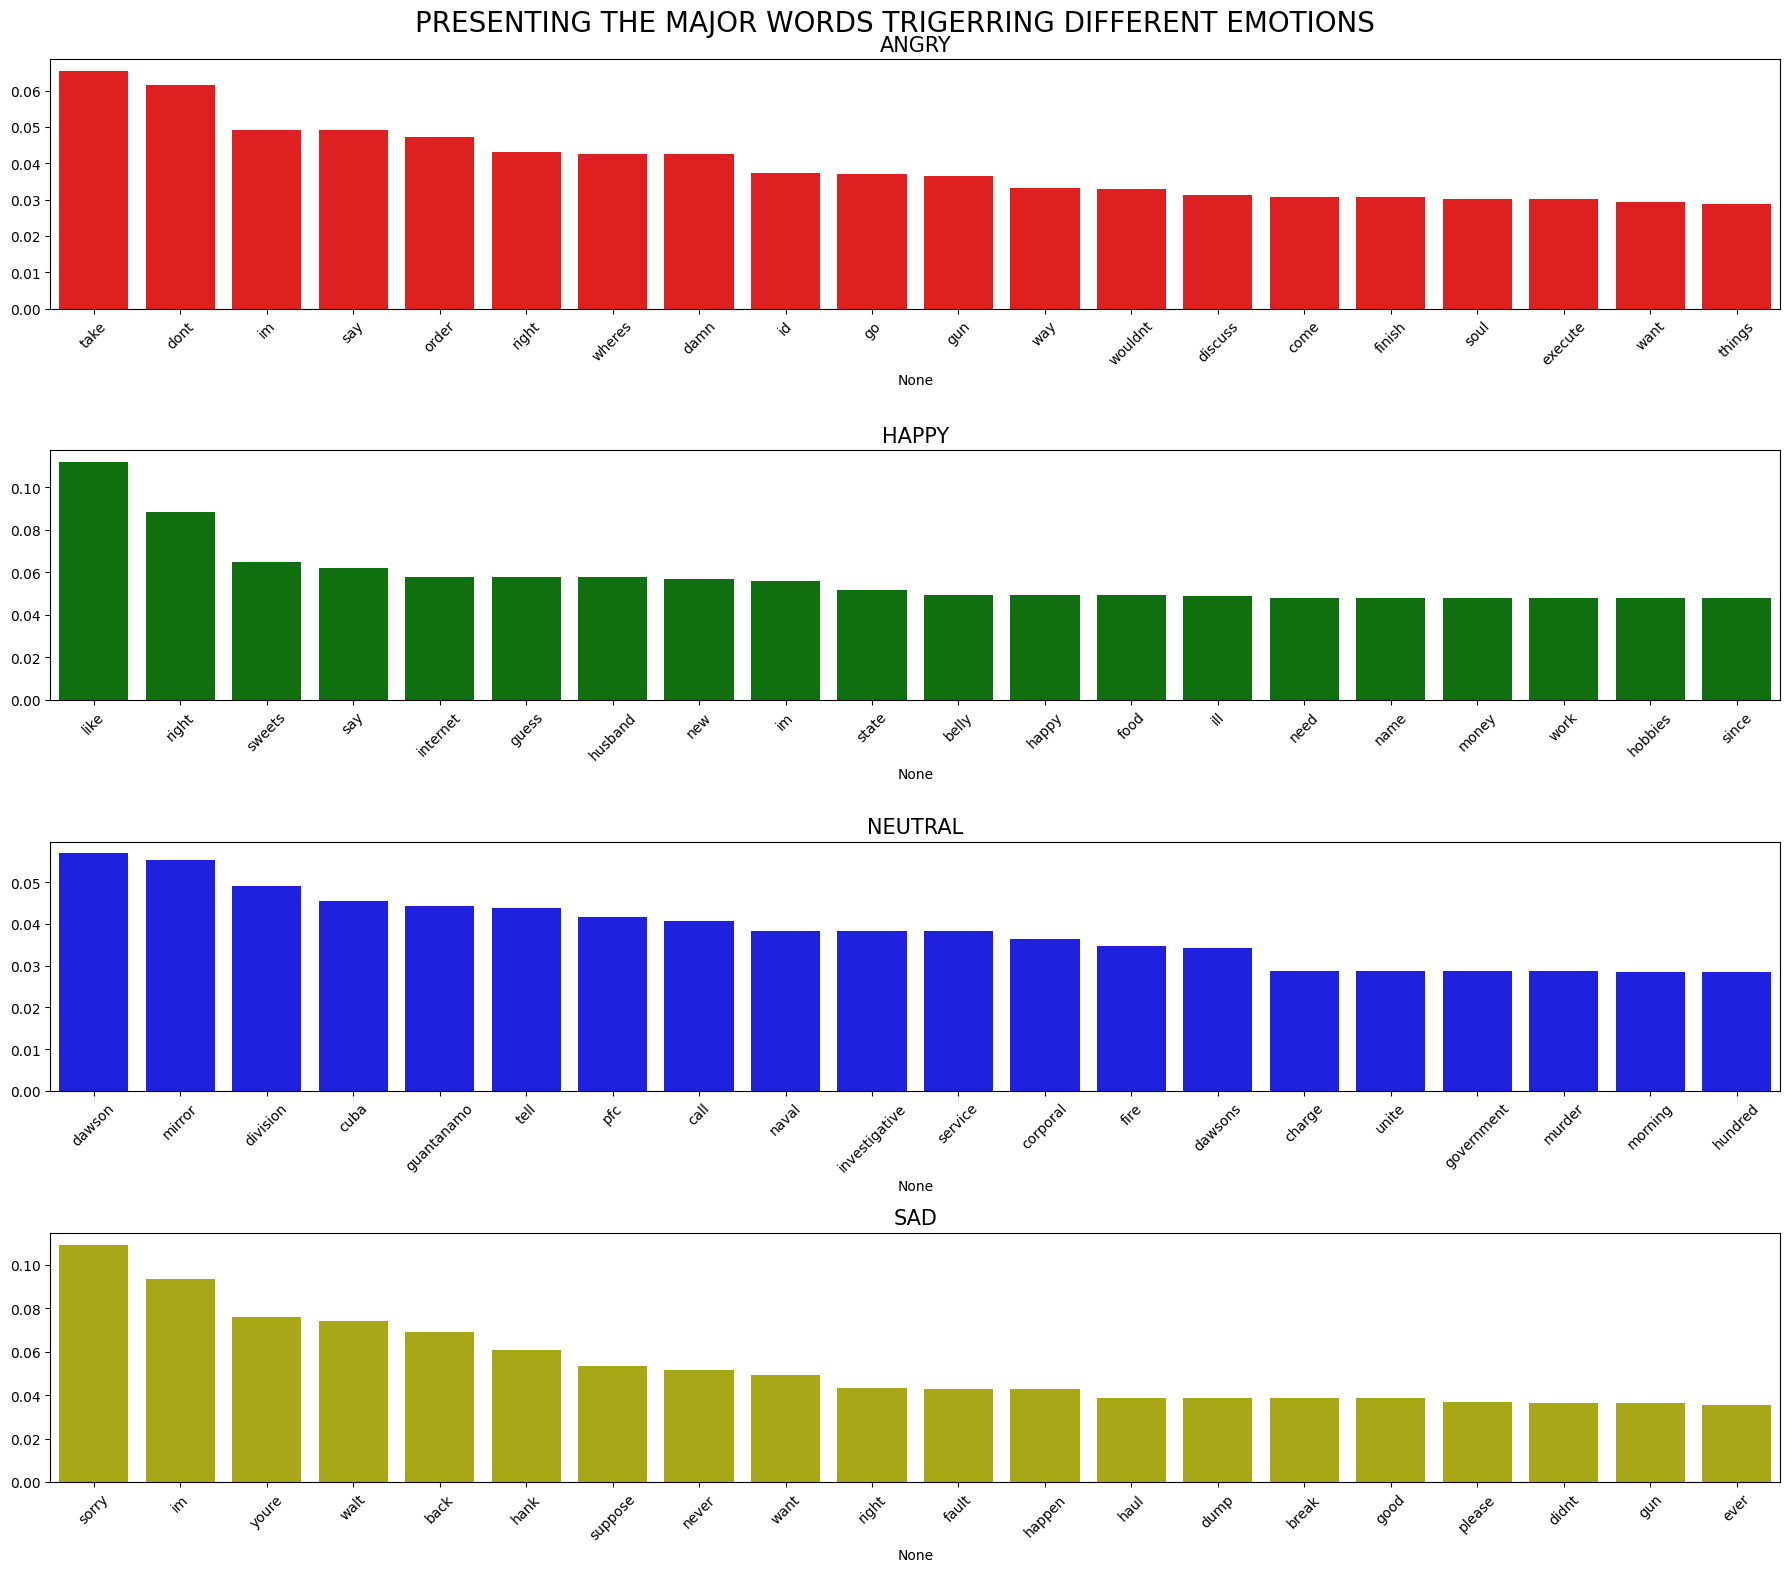

In [26]:
fig, axes = plt.subplots(4, 1, figsize=(18,16))

sns.barplot(x=angry.index, y=angry.values, ax=axes[0], color='r')
axes[0].set_title('ANGRY', fontsize=15)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=happy.index, y=happy.values, ax=axes[1], color='g')
axes[1].set_title('HAPPY', fontsize=15)
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x=neutral.index, y=neutral.values, ax=axes[2], color='b')
axes[2].set_title('NEUTRAL', fontsize=15)
axes[2].tick_params(axis='x', rotation=45)

sns.barplot(x=sad.index, y=sad.values, ax=axes[3], color='y')
axes[3].set_title('SAD', fontsize=15)
axes[3].tick_params(axis='x', rotation=45)


plt.suptitle("PRESENTING THE MAJOR WORDS TRIGERRING DIFFERENT EMOTIONS", fontsize=20)
plt.tight_layout()
plt.show()

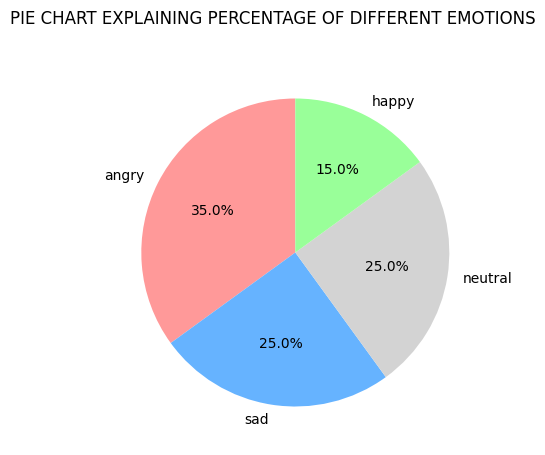

In [32]:
# plotting pie chart
counts = data_math['label'].value_counts()

color_map = {
    'angry': '#ff9999',   # Light Red
    'happy': '#99ff99',   # Light Green
    'sad': '#66b3ff',     # Light Blue
    'neutral': '#d3d3d3'  # Light Gray
}
custom_colors = [color_map[word] for word in counts.index]

# --------------------------------------------------------------------------------

plt.figure(figsize=(18,5))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=custom_colors
)


plt.suptitle("PIE CHART EXPLAINING PERCENTAGE OF DIFFERENT EMOTIONS")
plt.show()

**Since now we are done with all the EDA, we will now be moving to the Word2Vec**

---

In [34]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.4 MB/s eta 0:00:00


In [35]:
from gensim.models import word2vec

In [38]:
data.head()

,id,text,label
0,1,didnt even want go everyhere go people look li...,0
1,2,speak passionately something wasnt witness,0
2,3,everything ever care go,3
3,4,want doctor anything help people cant im kid,3
4,5,push towards success mentor gps announce youve...,1
